In [12]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv(
    "../data/processed/energy_market_data.csv",
    parse_dates=["date"]
)

data.head()

,date,power_price,volume_mwh,gas_price
0,2017-01-03,34.39,36000.0,3.41
1,2017-01-04,38.59,41600.0,3.42
2,2017-01-05,45.24,56000.0,3.42
3,2017-01-06,50.89,100000.0,3.38
4,2017-01-09,40.17,60800.0,3.14


In [13]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         2149 non-null   datetime64[us]
 1   power_price  2149 non-null   float64       
 2   volume_mwh   2149 non-null   float64       
 3   gas_price    2149 non-null   float64       
dtypes: datetime64[us](1), float64(3)
memory usage: 67.3 KB


In [14]:
data.describe()

,date,power_price,volume_mwh,gas_price
count,2149,2149.000000,2149.000000,2149.000000
mean,2021-05-26 04:22:00.055840,44.619200,19744.625407,3.240121
min,2017-01-03 00:00:00,0.000000,800.000000,1.210000
25%,2019-02-28 00:00:00,29.300000,8800.000000,2.420000
50%,2021-05-11 00:00:00,36.060000,16000.000000,2.860000
75%,2023-08-15 00:00:00,48.880000,26400.000000,3.360000
max,2025-12-23 00:00:00,366.910000,123200.000000,23.860000
std,NaN,27.203312,14887.896588,1.574160


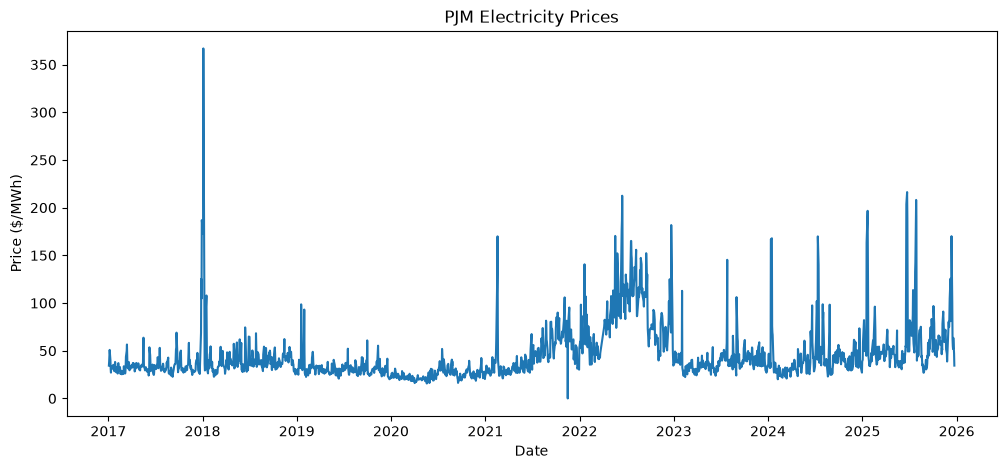

In [15]:
plt.figure(figsize=(12,5))
plt.plot(data["date"], data["power_price"])
plt.xlabel("Date")
plt.ylabel("Price ($/MWh)")
plt.title("PJM Electricity Prices")
plt.show()

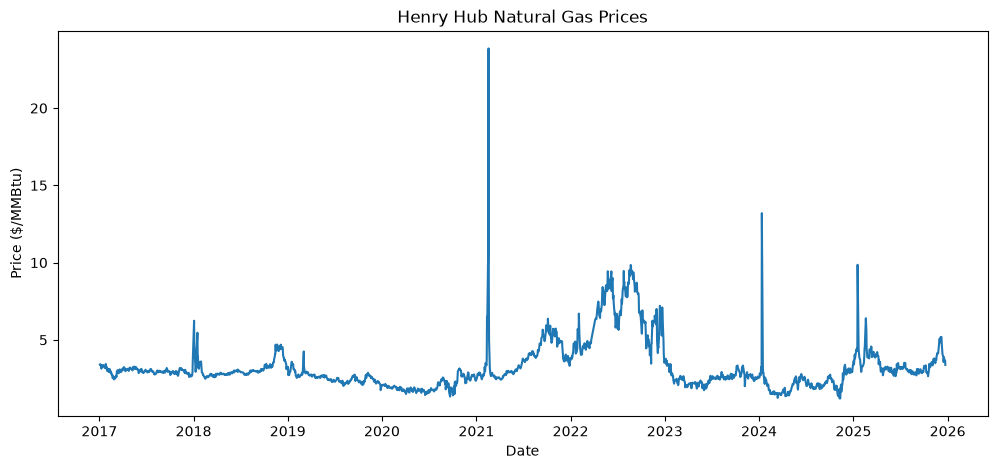

In [16]:
plt.figure(figsize=(12,5))
plt.plot(data["date"], data["gas_price"])
plt.xlabel("Date")
plt.ylabel("Price ($/MMBtu)")
plt.title("Henry Hub Natural Gas Prices")
plt.show()

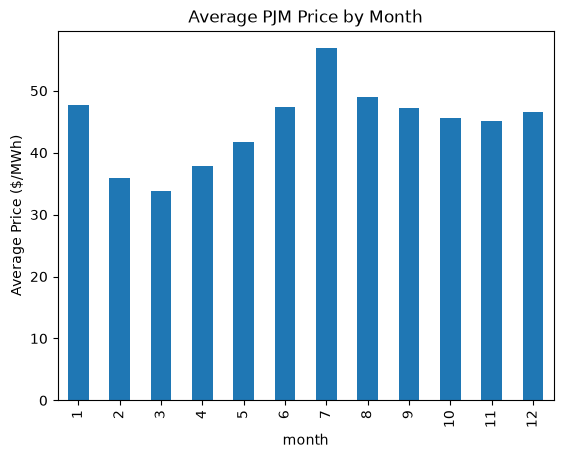

In [17]:
data["month"] = data["date"].dt.month

monthly = data.groupby("month")["power_price"].mean()

monthly.plot(kind="bar")
plt.ylabel("Average Price ($/MWh)")
plt.title("Average PJM Price by Month")
plt.show()

In [18]:
corr = data[
    ["power_price", "gas_price", "volume_mwh"]
].corr()

corr

,power_price,gas_price,volume_mwh
power_price,1.000000,0.705777,0.118924
gas_price,0.705777,1.000000,-0.057431
volume_mwh,0.118924,-0.057431,1.000000


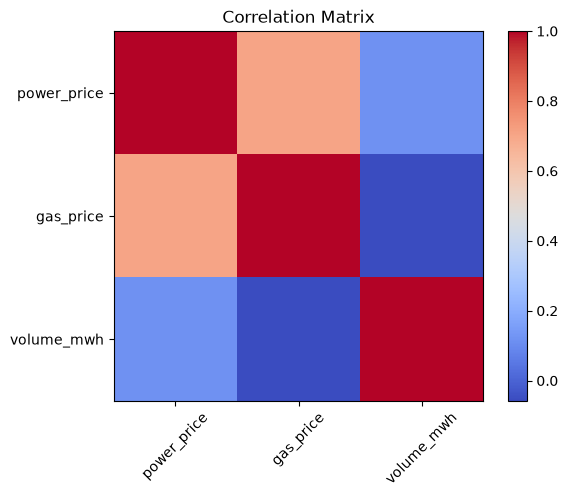

In [19]:
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()

plt.xticks(range(3), corr.columns, rotation=45)
plt.yticks(range(3), corr.columns)

plt.title("Correlation Matrix")
plt.show()

#### Feature engineering

In [20]:
data["power_lag1"] = data["power_price"].shift(1)
data["power_lag7"] = data["power_price"].shift(7)
data["gas_lag1"] = data["gas_price"].shift(1)

data = data.dropna()

In [21]:
# More price history
data["power_lag2"] = data["power_price"].shift(2)
data["power_lag30"] = data["power_price"].shift(30)

# Rolling behavior
data["power_ma7"] = data["power_price"].shift(1).rolling(7).mean()
data["power_std7"] = data["power_price"].shift(1).rolling(7).std()

# Gas history
data["gas_lag7"] = data["gas_price"].shift(7)

# Calendar
data["dayofweek"] = data["date"].dt.dayofweek

data = data.dropna()

In [22]:
data[
    ["power_price", "gas_price", "volume_mwh",
     "power_lag1", "power_lag2", "power_lag7", "power_lag30",
     "power_ma7", "power_std7",
     "gas_lag1", "gas_lag7",
     "month", "dayofweek"]
].corr()["power_price"].sort_values(ascending=False)

power_price    1.000000
power_lag1     0.798011
power_ma7      0.711392
gas_price      0.706650
gas_lag1       0.689185
power_lag2     0.664565
gas_lag7       0.584146
power_lag7     0.514888
power_lag30    0.428421
power_std7     0.374669
volume_mwh     0.127253
month          0.092830
dayofweek      0.012558
Name: power_price, dtype: float64

In [23]:
data.to_csv(
    "../data/processed/energy_features.csv",
    index=False
)